# Deep Learning Assignment — Image Classification
## Parts I, II, and III: CNN, Regularization, and Transfer Learning

**Dataset:** Imagenette (10-class subset of ImageNet) and CIFAR-10  
**Framework:** PyTorch Lightning

---

In [1]:
# Installing required packages
!pip install pytorch-lightning torchmetrics matplotlib

# Downloading Imagenette dataset
!wget -q https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
!tar -xzf imagenette2-160.tgz

In [18]:
import shutil
import os

os.makedirs('/content/drive/MyDrive/checkpoints', exist_ok=True)

shutil.copy('./checkpoints/best_regularized_cnn.ckpt',
            '/content/drive/MyDrive/checkpoints/best_regularized_cnn.ckpt')

shutil.copy('./checkpoints/best_scratch_cifar.ckpt',
            '/content/drive/MyDrive/checkpoints/best_scratch_cifar.ckpt')

print('Checkpoints saved to Google Drive!')

Checkpoints saved to Google Drive!


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder, CIFAR10

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torchmetrics.classification import MulticlassAccuracy

# Reproducibility
pl.seed_everything(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device: cuda


---
## Part I — Basic CNN on Imagenette

### Architecture Overview
- **3 convolutional blocks**, each with: Conv2d → BatchNorm → ReLU → MaxPool
- **2 fully connected layers** at the end for classification into 10 classes
- **Early Stopping** via PyTorch Lightning's callback (patience=5)

Input images are resized to **128×128** for speed. The 10 Imagenette classes are:
tench, English springer, cassette player, chain saw, church, French horn,
garbage truck, gas pump, golf ball, parachute.

In [3]:
# ── Data transformation (no augmentation for Part I) ──────────────────────────────
IMG_SIZE = 128
BATCH_SIZE = 64
IMAGENETTE_PATH = './imagenette2-160'

base_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

train_dataset = ImageFolder(root=os.path.join(IMAGENETTE_PATH, 'train'),
                            transform=base_transform)
val_dataset   = ImageFolder(root=os.path.join(IMAGENETTE_PATH, 'val'),
                            transform=base_transform)

# Using val set as both validation and test
val_size  = int(0.5 * len(val_dataset))
test_size = len(val_dataset) - val_size
val_data, test_data = random_split(val_dataset, [val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,      batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train: {len(train_dataset)} | Val: {len(val_data)} | Test: {len(test_data)}')

Train: 9469 | Val: 1962 | Test: 1963


In [4]:
# ── CNN Architecture ──
class BasicCNN(pl.LightningModule):
    """
    3-block CNN for 10-class image classification.
    Each block: Conv2d(k=3,p=1) -> BatchNorm -> ReLU -> MaxPool(2)
    Final head: Flatten -> FC(512) -> ReLU -> Dropout -> FC(10)
    """
    def __init__(self, num_classes=10, lr=1e-3, dropout_p=0.0):
        super().__init__()
        self.save_hyperparameters()
        self.lr = lr
        self.train_losses, self.val_losses = [], []

        self.features = nn.Sequential(
            # Block 1: 3 -> 32 channels, 128 -> 64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 2: 32 -> 64 channels, 64 -> 32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            # Block 3: 64 -> 128 channels, 32 -> 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # After 3 x MaxPool(2): 128 -> 16; feature map = 128 * 16 * 16
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(512, num_classes),
        )
        self.accuracy = MulticlassAccuracy(num_classes=num_classes)

    def forward(self, x):
        return self.classifier(self.features(x))

    def _shared_step(self, batch):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc  = self.accuracy(logits, y)
        return loss, acc

    def training_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        self.log('train_acc',  acc,  on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True)
        self.log('val_acc',  acc,  on_epoch=True, prog_bar=True)

    def test_step(self, batch, batch_idx):
        loss, acc = self._shared_step(batch)
        self.log('test_loss', loss)
        self.log('test_acc',  acc)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )
        return {'optimizer': optimizer,
                'lr_scheduler': {'scheduler': scheduler, 'monitor': 'val_loss'}}


print('Model defined.')
model_v1 = BasicCNN(num_classes=10, lr=1e-3, dropout_p=0.0)
print(model_v1)

Model defined.
BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_featu

In [5]:
# ── Training — Part I ───
early_stop_cb = EarlyStopping(monitor='val_loss', patience=5, mode='min', verbose=True)
ckpt_cb_v1    = ModelCheckpoint(monitor='val_loss', save_top_k=1,
                                 filename='best_basic_cnn', dirpath='./checkpoints')

trainer_v1 = pl.Trainer(
    max_epochs=30,
    callbacks=[early_stop_cb, ckpt_cb_v1],
    accelerator='auto',
    log_every_n_steps=10,
)

trainer_v1.fit(model_v1, train_loader, val_loader)
test_result_v1 = trainer_v1.test(model_v1, test_loader, ckpt_path='best')
print('\nPart I Test Results:', test_result_v1)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential         │ 93.7 K │ train │     0 │
│ 1 │ classifier │ Sequential         │ 16.8 M │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 16.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.9 M                                                                                               
Total estimated model params size (MB): 67                                                                         
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved. New best score: 1.516
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.148 >= min_delta = 0.0. New best score: 1.368
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.041 >= min_delta = 0.0. New best score: 1.327
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.198 >= min_delta = 0.0. New best score: 1.129
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_loss improved by 0.013 >= min_delta = 0.0. New best score: 1.116
INFO:pytorch_lightning.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 5 records. Best score: 1.116. Signaling Trainer to stop.


INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/best_basic_cnn.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/best_basic_cnn.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6519144773483276     │
│         test_loss         │     1.119805097579956     │
└───────────────────────────┴───────────────────────────┘


Part I Test Results: [{'test_loss': 1.119805097579956, 'test_acc': 0.6519144773483276}]


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential         │ 93.7 K │ train │     0 │
│ 1 │ classifier │ Sequential         │ 16.8 M │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 16.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.9 M                                                                                               
Total estimated model params size (MB): 67                                                                         
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/best_basic_cnn-v1.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/best_basic_cnn-v1.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.6530743837356567     │
│         test_loss         │    1.0972023010253906     │
└───────────────────────────┴───────────────────────────┘

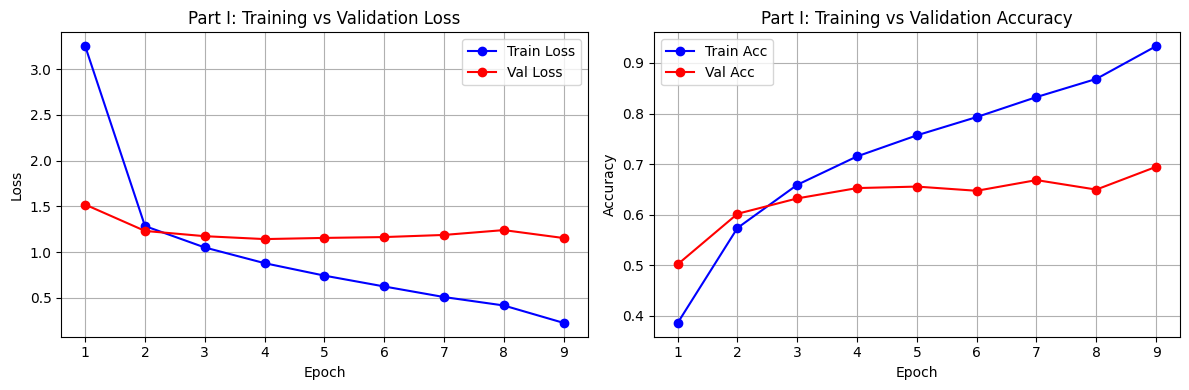


Part I Final Test Accuracy: 0.6531


In [6]:
# ── Plot Part I — Training & Validation Loss ───
def get_metric(trainer, key):
    """Extract per-epoch metric from Lightning trainer logs."""
    metrics = trainer.logged_metrics

    history = []
    for cb in trainer.loggers:
        if hasattr(cb, 'experiment') and hasattr(cb.experiment, 'metrics'):
            history = [m[key] for m in cb.experiment.metrics if key in m]
    return history

# Re-training with CSVLogger to capture epoch histories easily
from pytorch_lightning.loggers import CSVLogger
import pandas as pd

logger_v1 = CSVLogger('.', name='logs_v1')
trainer_v1b = pl.Trainer(
    max_epochs=30,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, mode='min'),
        ModelCheckpoint(monitor='val_loss', save_top_k=1,
                        filename='best_basic_cnn', dirpath='./checkpoints'),
    ],
    accelerator='auto',
    logger=logger_v1,
    log_every_n_steps=10,
)
model_v1b = BasicCNN(num_classes=10, lr=1e-3, dropout_p=0.0)
trainer_v1b.fit(model_v1b, train_loader, val_loader)
result_v1 = trainer_v1b.test(model_v1b, test_loader, ckpt_path='best')

# Read and plot logs
log_path = logger_v1.experiment.metrics_file_path
df_v1 = pd.read_csv(log_path)

train_loss_v1 = df_v1.dropna(subset=['train_loss_epoch'])['train_loss_epoch'].values
val_loss_v1   = df_v1.dropna(subset=['val_loss'])['val_loss'].values
epochs_v1 = range(1, len(train_loss_v1) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_v1, train_loss_v1, 'b-o', label='Train Loss')
axes[0].plot(range(1, len(val_loss_v1)+1), val_loss_v1, 'r-o', label='Val Loss')
axes[0].set_title('Part I: Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

train_acc_v1 = df_v1.dropna(subset=['train_acc_epoch'])['train_acc_epoch'].values
val_acc_v1   = df_v1.dropna(subset=['val_acc'])['val_acc'].values
axes[1].plot(range(1, len(train_acc_v1)+1), train_acc_v1, 'b-o', label='Train Acc')
axes[1].plot(range(1, len(val_acc_v1)+1), val_acc_v1, 'r-o', label='Val Acc')
axes[1].set_title('Part I: Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('part1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPart I Final Test Accuracy: {result_v1[0]['test_acc']:.4f}")

### Part I Results

**Architecture Summary:**
| Layer | Output Size | Details |
|---|---|---|
| Input | 3×128×128 | RGB image |
| Conv Block 1 | 32×64×64 | Conv(3,32), BN, ReLU, MaxPool |
| Conv Block 2 | 64×32×32 | Conv(32,64), BN, ReLU, MaxPool |
| Conv Block 3 | 128×16×16 | Conv(64,128), BN, ReLU, MaxPool |
| FC 1 | 512 | Linear, ReLU |
| FC 2 (Output) | 10 | Linear (logits) |

- **Optimizer:** Adam (lr=1e-3), ReduceLROnPlateau scheduler
- **Early Stopping:** patience=5 on `val_loss`
- **Batch size:** 64

---
## Part II — Regularization

Two forms of regularization:
1. **Data Augmentation** — Random horizontal flip, random crop, color jitter
2. **Dropout** — p=0.5 in the classifier head

These help the model generalize by making it harder to memorize training samples.

In [7]:
# ── Augmented Transform ──
aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Training with augmentation; val/test keep base transform
train_aug_dataset = ImageFolder(root=os.path.join(IMAGENETTE_PATH, 'train'),
                                transform=aug_transform)
train_aug_loader  = DataLoader(train_aug_dataset, batch_size=BATCH_SIZE,
                               shuffle=True, num_workers=2, pin_memory=True)

print('Augmented train loader ready.')

Augmented train loader ready.


In [8]:
# ── Train regularized model ──
logger_v2 = CSVLogger('.', name='logs_v2')
trainer_v2 = pl.Trainer(
    max_epochs=50,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=7, mode='min'), #changed patience to 7
        ModelCheckpoint(monitor='val_loss', save_top_k=1,
                        filename='best_regularized_cnn', dirpath='./checkpoints'),
    ],
    accelerator='auto',
    logger=logger_v2,
    log_every_n_steps=10,
)

model_v2 = BasicCNN(num_classes=10, lr=1e-3, dropout_p=0.3)  # dropout=0.3
trainer_v2.fit(model_v2, train_aug_loader, val_loader)        # augmented train data
result_v2 = trainer_v2.test(model_v2, test_loader, ckpt_path='best')
print('\nPart II Test Results:', result_v2)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential         │ 93.7 K │ train │     0 │
│ 1 │ classifier │ Sequential         │ 16.8 M │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 16.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.9 M                                                                                               
Total estimated model params size (MB): 67                                                                         
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/best_regularized_cnn.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/best_regularized_cnn.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │     0.781903862953186     │
│         test_loss         │    0.6728731393814087     │
└───────────────────────────┴───────────────────────────┘


Part II Test Results: [{'test_loss': 0.6728731393814087, 'test_acc': 0.781903862953186}]


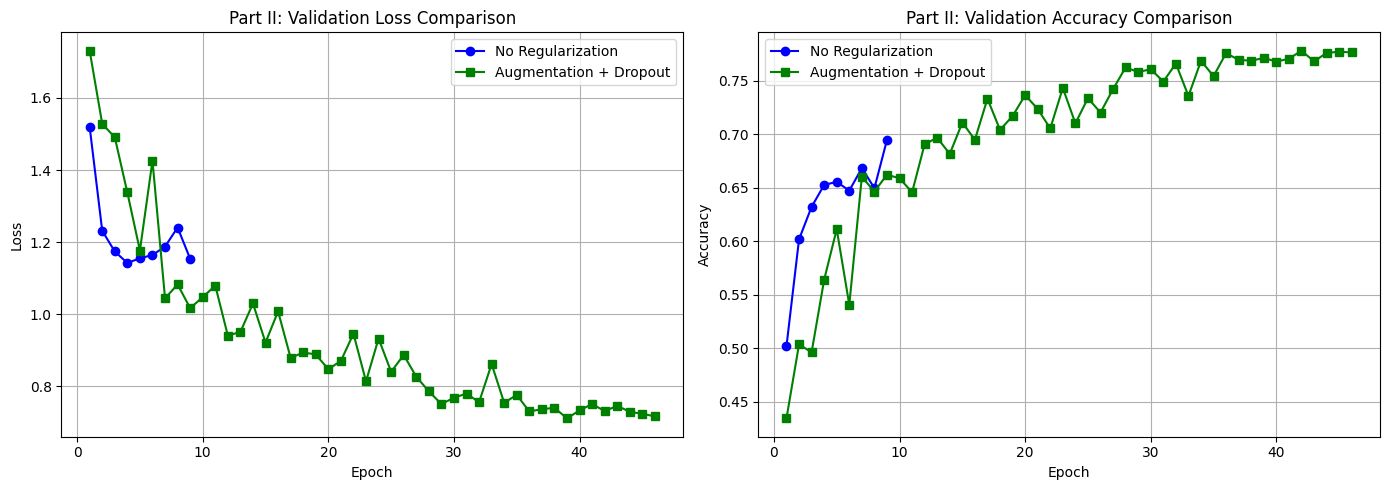


No Regularization  — Test Accuracy: 0.6531
With Regularization — Test Accuracy: 0.7819


In [9]:
# ── Comparison Plot: With vs Without Regularization ──
df_v2 = pd.read_csv(logger_v2.experiment.metrics_file_path)

train_loss_v2 = df_v2.dropna(subset=['train_loss_epoch'])['train_loss_epoch'].values
val_loss_v2   = df_v2.dropna(subset=['val_loss'])['val_loss'].values
val_acc_v2    = df_v2.dropna(subset=['val_acc'])['val_acc'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val Loss comparison
axes[0].plot(range(1, len(val_loss_v1)+1), val_loss_v1, 'b-o', label='No Regularization')
axes[0].plot(range(1, len(val_loss_v2)+1), val_loss_v2, 'g-s', label='Augmentation + Dropout')
axes[0].set_title('Part II: Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Val Accuracy comparison
axes[1].plot(range(1, len(val_acc_v1)+1), val_acc_v1, 'b-o', label='No Regularization')
axes[1].plot(range(1, len(val_acc_v2)+1), val_acc_v2, 'g-s', label='Augmentation + Dropout')
axes[1].set_title('Part II: Validation Accuracy Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('part2_regularization_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNo Regularization  — Test Accuracy: {result_v1[0]['test_acc']:.4f}")
print(f"With Regularization — Test Accuracy: {result_v2[0]['test_acc']:.4f}")

### Part II: Regularization Description

**Data Augmentation applied (training set only):**
| Technique | Parameters | Purpose |
|---|---|---|
| RandomCrop | 128×128 from 144×144 | Positional invariance |
| RandomHorizontalFlip | p=0.5 | Mirror symmetry |
| ColorJitter | brightness/contrast/saturation=0.3, hue=0.1 | Lighting robustness |

**Dropout:** p=0.5 applied after the first fully-connected layer.

**Expected outcome:** The regularized model should show a smaller gap between training and validation performance, indicating better generalization.


Part III — Transfer Learning
Strategy:

Saved the weights from our best Imagenette model (Part II)

Created the same architecture adapted for CIFAR-10 (also 10 classes)

Trained it from scratch on CIFAR-10 → baseline

Trained it initialized with Imagenette weights (fine-tuning) → transfer learning

Compared convergence speed and final accuracy **bold text** bold text

> Add blockquote



The convolutional layers learn low-level features (edges, textures) that transfer across datasets. Only the high-level representations differ.

> Add blockquote



In [10]:
# ── CIFAR-10 DataLoaders ──
# CIFAR-10 images are 32×32 — resized to 128×128 to match our CNN input
cifar_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],   # CIFAR-10 stats
                         std=[0.2023, 0.1994, 0.2010]),
])

cifar_aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std=[0.2023, 0.1994, 0.2010]),
])

cifar_train = CIFAR10(root='./data', train=True,  download=True, transform=cifar_aug_transform)
cifar_test  = CIFAR10(root='./data', train=False, download=True, transform=cifar_transform)

# Split train into train/val
n_val = int(0.1 * len(cifar_train))
cifar_train_data, cifar_val_data = random_split(cifar_train, [len(cifar_train)-n_val, n_val])

cifar_train_loader = DataLoader(cifar_train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
cifar_val_loader   = DataLoader(cifar_val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
cifar_test_loader  = DataLoader(cifar_test,        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'CIFAR-10 — Train: {len(cifar_train_data)} | Val: {len(cifar_val_data)} | Test: {len(cifar_test)}')

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


CIFAR-10 — Train: 45000 | Val: 5000 | Test: 10000


In [11]:
# ── 3A: Train from scratch on CIFAR-10 ──
logger_v3a = CSVLogger('.', name='logs_v3_scratch')

model_scratch = BasicCNN(num_classes=10, lr=1e-3, dropout_p=0.3)

trainer_v3a = pl.Trainer(
    max_epochs=60, #patience and epoch changed
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, mode='min'),
        ModelCheckpoint(monitor='val_loss', save_top_k=1,
                        filename='best_scratch_cifar', dirpath='./checkpoints'),
    ],
    accelerator='auto',
    logger=logger_v3a,
    log_every_n_steps=10,
)

trainer_v3a.fit(model_scratch, cifar_train_loader, cifar_val_loader)
result_scratch = trainer_v3a.test(model_scratch, cifar_test_loader, ckpt_path='best')
print('\nScratch CIFAR-10 Test Results:', result_scratch)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential         │ 93.7 K │ train │     0 │
│ 1 │ classifier │ Sequential         │ 16.8 M │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 16.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.9 M                                                                                               
Total estimated model params size (MB): 67                                                                         
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=60` reached.


INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/checkpoints/best_scratch_cifar.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/checkpoints/best_scratch_cifar.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7610042095184326     │
│         test_loss         │    0.6896587610244751     │
└───────────────────────────┴───────────────────────────┘


Scratch CIFAR-10 Test Results: [{'test_loss': 0.6896587610244751, 'test_acc': 0.7610042095184326}]


In [21]:
# ── 3B: Fine-tune from Imagenette pre-trained weights ──
# Load best Imagenette checkpoint and copy feature extractor weights
imagenette_ckpt = imagenette_ckpt = '/content/drive/MyDrive/checkpoints/best_regularized_cnn.ckpt'


# Build model with same architecture (10 classes — both datasets have 10)
model_finetune = BasicCNN(num_classes=10, lr=3e-4, dropout_p=0.3)  # lowering lr and p for fine-tuning

# Load Imagenette weights (strict=False ignores mismatched keys if any)
pretrained_state = torch.load(imagenette_ckpt, map_location='cpu')['state_dict']
model_finetune.load_state_dict(pretrained_state, strict=True)
print('Imagenette pre-trained weights loaded successfully.')

for param in model_finetune.features.parameters():
    param.requires_grad = True   # allow full fine-tuning (unfreeze all)

logger_v3b = CSVLogger('.', name='logs_v3_finetune')

trainer_v3b = pl.Trainer(
    max_epochs=60,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, mode='min'),
        ModelCheckpoint(monitor='val_loss', save_top_k=1,
                        filename='best_finetune_cifar', dirpath='./checkpoints'),
    ],
    accelerator='auto',
    logger=logger_v3b,
    log_every_n_steps=10,
)

trainer_v3b.fit(model_finetune, cifar_train_loader, cifar_val_loader)
result_finetune = trainer_v3b.test(model_finetune, cifar_test_loader, ckpt_path='best')
print('\nFine-tuned CIFAR-10 Test Results:', result_finetune)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /content/checkpoints exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Imagenette pre-trained weights loaded successfully.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ features   │ Sequential         │ 93.7 K │ train │     0 │
│ 1 │ classifier │ Sequential         │ 16.8 M │ train │     0 │
│ 2 │ accuracy   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 16.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 16.9 M                                                                                               
Total estimated model params size (MB): 67                                                                         
Modules in train mode: 20                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

FileNotFoundError: [Errno 2] No such file or directory

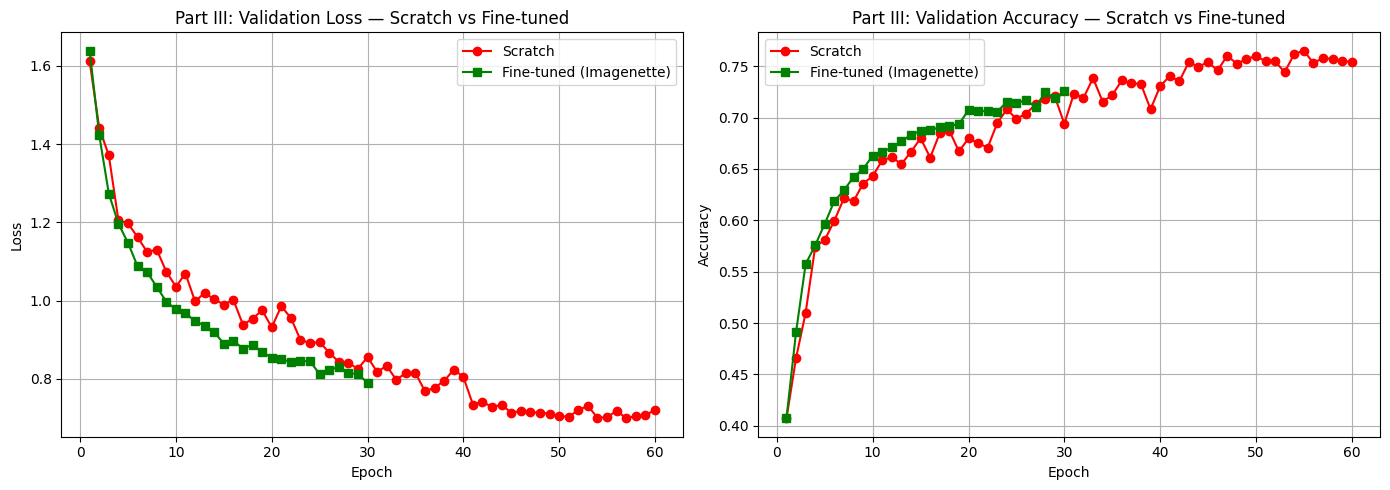


FINAL RESULTS SUMMARY
Part I  — Imagenette (No Reg.)  Test Acc: 0.6531
Part II — Imagenette (With Reg.) Test Acc: 0.7819
Part III — CIFAR-10 Scratch      Test Acc: 0.7610
Part III — CIFAR-10 Fine-tuned   Test Acc: 0.7194


In [20]:
# ── Part III Comparison Plot ──
df_scratch   = pd.read_csv(logger_v3a.experiment.metrics_file_path)
df_finetune  = pd.read_csv(logger_v3b.experiment.metrics_file_path)

val_loss_scratch  = df_scratch.dropna(subset=['val_loss'])['val_loss'].values
val_acc_scratch   = df_scratch.dropna(subset=['val_acc'])['val_acc'].values
val_loss_ft       = df_finetune.dropna(subset=['val_loss'])['val_loss'].values
val_acc_ft        = df_finetune.dropna(subset=['val_acc'])['val_acc'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(val_loss_scratch)+1), val_loss_scratch, 'r-o', label='Scratch')
axes[0].plot(range(1, len(val_loss_ft)+1),      val_loss_ft,      'g-s', label='Fine-tuned (Imagenette)')
axes[0].set_title('Part III: Validation Loss — Scratch vs Fine-tuned')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, len(val_acc_scratch)+1), val_acc_scratch, 'r-o', label='Scratch')
axes[1].plot(range(1, len(val_acc_ft)+1),      val_acc_ft,      'g-s', label='Fine-tuned (Imagenette)')
axes[1].set_title('Part III: Validation Accuracy — Scratch vs Fine-tuned')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('part3_transfer_learning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"Part I  — Imagenette (No Reg.)  Test Acc: {result_v1[0]['test_acc']:.4f}")
print(f"Part II — Imagenette (With Reg.) Test Acc: {result_v2[0]['test_acc']:.4f}")
print(f"Part III — CIFAR-10 Scratch      Test Acc: {result_scratch[0]['test_acc']:.4f}")
print(f"Part III — CIFAR-10 Fine-tuned   Test Acc: {result_finetune[0]['test_acc']:.4f}")
print("="*50)